# **Machine Learning Project - A ML Regression Problem Example**

<h1>Machine Learning Pipeline (for molecules)<h1>

<h5> 1. Define the application </h5>
<h5> 2. Load data (smiles + target values)</h5>
<h5> 3. Explore, standardize and clean data  </h5>
<h5> 4. Featurize molecules (descriptors / fingerprints) </h5>
<h5> 5. Split data (training and test set) </h5>
<h5> 6. Choose and build ML model (classification / regression) </h5>
<h5> 7. Train model on training set </h5>
<h5> 8. Evaluate model on test set </h5>
<h5> 9. Improve model (optimization, hyperparamater tuning, etc) </h5>
<h5> 10. Save, Load, Use model for predictions on new data </h5>
<h5> 11. Optional: Deploy model </h5>

<h5>

>**Machine Learning Pipeline:  
Data → Features → Model → Train → Evaluation → Optimization → Prediction**  

</h5>

In [1]:
# Install rdkit
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 25.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

## 1 Define application

---



Predict retention index of hydrocarbon molecules in gas chromatography using a non-polar GC column

- X: smiles (convert to descriptors)
- y: retention index

## 2 Load data

In [5]:
import requests

# URL of the pickle file
url = 'https://github.com/DrCOAST/coast-python/raw/main/data/processed_df.pkl'

# Download the file
response = requests.get(url)
with open('processed_df.pkl', 'wb') as f:
    f.write(response.content)

# Load the data
df = pd.read_pickle('processed_df.pkl')
df

,SMILES,RETENTION_INDEX,SpectrumID
0,CCCCCCCCCCCCCCC(C)CCCCCCCCCCCCCC,2928.0,2627482
1,CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CC,2973.0,2627317
3,CCCCCCCCCCCCCCCCCCC(C)CCCCCCCCCC,2932.0,2629203
4,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,3000.0,2627485
10,CCCCCCCCCCCCCCCCC(C)CCCCCCCCCCCC,2931.0,2626252
...,...,...,...
1307,CCCCCC,554.0,1116675
1315,CC(C)C(C)C,600.0,2874132
1322,CC(C)(C)C,567.0,2869632
1327,CCCCC,412.0,2874089


## 3 Explore, standardize and clean data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, 0 to 1335
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SMILES           501 non-null    object 
 1   RETENTION_INDEX  501 non-null    float64
 2   SpectrumID       501 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.7+ KB


In [7]:
# remove 'not a number'
df = df.dropna()
len(df)

501

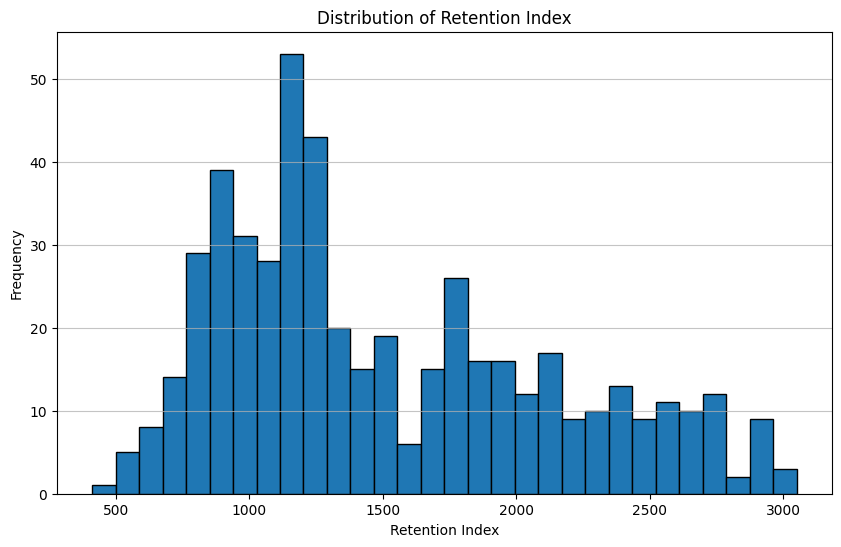

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['RETENTION_INDEX'], bins=30, edgecolor='black')
plt.title('Distribution of Retention Index')
plt.xlabel('Retention Index')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [9]:
# add mol objects
from rdkit import Chem
from rdkit.Chem import AllChem
df['mol'] = df['SMILES'].apply(Chem.MolFromSmiles)

In [10]:
# drop invalid smiles
df = df.dropna(subset=['mol'])

In [11]:
# add canonical smiles from mol objects
df['canonical_smiles'] = df['mol'].apply(Chem.MolToSmiles)

In [12]:
# remove duplicate canonical smiles
df = df.drop_duplicates(subset=['canonical_smiles'])

In [13]:
# reset index
df = df.reset_index(drop=True)

In [14]:
df

,SMILES,RETENTION_INDEX,SpectrumID,mol,canonical_smiles
0,CCCCCCCCCCCCCCC(C)CCCCCCCCCCCCCC,2928.0,2627482,<rdkit.Chem.rdchem.Mol object at 0x7943d019af10>,CCCCCCCCCCCCCCC(C)CCCCCCCCCCCCCC
1,CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CC,2973.0,2627317,<rdkit.Chem.rdchem.Mol object at 0x7943d019aff0>,CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CC
2,CCCCCCCCCCCCCCCCCCC(C)CCCCCCCCCC,2932.0,2629203,<rdkit.Chem.rdchem.Mol object at 0x7943d019b060>,CCCCCCCCCCCCCCCCCCC(C)CCCCCCCCCC
3,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,3000.0,2627485,<rdkit.Chem.rdchem.Mol object at 0x7943d019b0d0>,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC
4,CCCCCCCCCCCCCCCCC(C)CCCCCCCCCCCC,2931.0,2626252,<rdkit.Chem.rdchem.Mol object at 0x7943d019b140>,CCCCCCCCCCCCCCCCC(C)CCCCCCCCCCCC
...,...,...,...,...,...
496,CCCCCC,554.0,1116675,<rdkit.Chem.rdchem.Mol object at 0x7943c5b58ac0>,CCCCCC
497,CC(C)C(C)C,600.0,2874132,<rdkit.Chem.rdchem.Mol object at 0x7943c5b58b30>,CC(C)C(C)C
498,CC(C)(C)C,567.0,2869632,<rdkit.Chem.rdchem.Mol object at 0x7943c5b58ba0>,CC(C)(C)C
499,CCCCC,412.0,2874089,<rdkit.Chem.rdchem.Mol object at 0x7943c5b58c10>,CCCCC


## 4 Featurize molecules

### 4.1 Descriptors

In [15]:
from rdkit.Chem import Descriptors
# CalcBalabanJ, CalcKappa1, CalcKappa2, CalcKappa3 are also available directly under Descriptors

# Calculate Molecular Weight
df['MolWt'] = df['mol'].apply(Descriptors.MolWt)

# Calculate LogP (octanol-water partition coefficient)
df['MolLogP'] = df['mol'].apply(Descriptors.MolLogP)

# Calculate Number of Hydrogen Bond Donors
df['NumHDonors'] = df['mol'].apply(Descriptors.NumHDonors)

# Calculate Number of Hydrogen Bond Acceptors
df['NumHAcceptors'] = df['mol'].apply(Descriptors.NumHAcceptors)

# Calculate Balaban's J Index (related to branching and size)
df['BalabanJ'] = df['mol'].apply(Descriptors.BalabanJ)

# Calculate Kappa Shape Indices (related to shape and branching)
df['Kappa1'] = df['mol'].apply(Descriptors.Kappa1)
df['Kappa2'] = df['mol'].apply(Descriptors.Kappa2)
df['Kappa3'] = df['mol'].apply(Descriptors.Kappa3)

df.head()

,SMILES,RETENTION_INDEX,SpectrumID,mol,canonical_smiles,MolWt,MolLogP,NumHDonors,NumHAcceptors,BalabanJ,Kappa1,Kappa2,Kappa3
0,CCCCCCCCCCCCCCC(C)CCCCCCCCCCCCCC,2928.0,2627482,<rdkit.Chem.rdchem.Mol object at 0x7943d019af10>,CCCCCCCCCCCCCCC(C)CCCCCCCCCCCCCC,422.826,11.8049,0,0,3.125471,30.0,27.034483,26.035714
1,CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CC,2973.0,2627317,<rdkit.Chem.rdchem.Mol object at 0x7943d019aff0>,CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CC,422.826,11.8049,0,0,3.003132,30.0,27.034483,26.035714
2,CCCCCCCCCCCCCCCCCCC(C)CCCCCCCCCC,2932.0,2629203,<rdkit.Chem.rdchem.Mol object at 0x7943d019b060>,CCCCCCCCCCCCCCCCCCC(C)CCCCCCCCCC,422.826,11.8049,0,0,3.107436,30.0,27.034483,26.035714
3,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,3000.0,2627485,<rdkit.Chem.rdchem.Mol object at 0x7943d019b0d0>,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,422.826,11.9490,0,0,2.972520,30.0,29.000000,28.000000
4,CCCCCCCCCCCCCCCCC(C)CCCCCCCCCCCC,2931.0,2626252,<rdkit.Chem.rdchem.Mol object at 0x7943d019b140>,CCCCCCCCCCCCCCCCC(C)CCCCCCCCCCCC,422.826,11.8049,0,0,3.120802,30.0,27.034483,26.035714


### 4.2 Fingerprints

For this model we only use descriptors, not fingerprints.

## 5 Split data

<h1> Scikit-learn and other ML/DL Libraries </h1>

**Scikit-learn (sklearn)** is a free software machine learning library for the Python programming language. It features various classification, regression, and clustering algorithms including support vector machines, random forests, gradient boosting, k-means, and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy. It's widely used for traditional machine learning tasks due to its simplicity, efficiency, and comprehensive documentation.

**When to use Scikit-learn:**
*   **Traditional ML tasks:** Classification, regression, clustering, dimensionality reduction.
*   **Structured data:** When your data is in tabular format (like dataframes).
*   **Small to medium datasets:** For very large datasets, deep learning frameworks might be more efficient.
*   **Interpretability:** Many scikit-learn models are more interpretable than complex deep learning models.
*   **Rapid prototyping:** Its consistent API makes it easy to experiment with different models quickly.


**Other Popular Machine Learning and Deep Learning Libraries:**

**Machine Learning:**
*   **XGBoost / LightGBM:** Highly efficient and scalable implementations of gradient boosting decision trees, often used for tabular data and competitive programming.
*   **Statsmodels:** Focuses on statistical modeling, providing a wide range of statistical tests, model estimation, and data exploration tools.

**Deep Learning:**
*   **TensorFlow:** An open-source machine learning platform developed by Google. It's a comprehensive ecosystem of tools, libraries, and community resources that lets researchers push the state-of-the-art in ML and developers easily build and deploy ML-powered applications.
*   **Keras:** A high-level neural networks API, written in Python and capable of running on top of TensorFlow, CNTK, or Theano. It's designed for fast experimentation with deep neural networks.
*   **PyTorch:** An open-source machine learning library developed by Facebook's AI Research lab (FAIR). It's known for its flexibility and ease of use, especially for research and development of deep learning models.

**For this project, we are using scikit-learn for its ease of use and effectiveness with structured chemical data.**

**Scikit-learn Installation**

Unlike `rdkit`, **scikit-learn (sklearn) is typically pre-installed in Google Colab environments.** This means you usually don't need to run a `!pip install sklearn` command. You can directly import and use its modules, as demonstrated by `from sklearn.model_selection import train_test_split` in the next section.

In [18]:
# split the data for ML
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# We split the data (random) in a train (80%) and a test set (20%)
# Both in a dataframe format: train_df and test_df

# Remark: The test set should not contain smiles which are also present in the train set

## 6 Choose and build model

Choose model:  

ML:  
- **Linear Regression**
- Random forest regressor  
- Gradient Boosting Regressor (XGBoost, LightGBM)
- Support Vector Regressor (SVR)
- K-nearest Neighbors Regressor

Deep Learning:
- CNN
- GNN

In [19]:
# Build a regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [20]:
descriptor_columns = ['MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'BalabanJ', 'Kappa1', 'Kappa2', 'Kappa3']

X_train_descriptors = train_df[descriptor_columns]    # X train --> descriptors
y_train = train_df['RETENTION_INDEX']                 # y train --> retention index

X_test_descriptors = test_df[descriptor_columns]      # X test --> descriptors
y_test = test_df['RETENTION_INDEX']                   # y test --> retention index


Feature Scaling (Normalization)

Feature scaling is an important preprocessing step, especially for models like Linear Regression. It ensures that all features contribute equally to the model by bringing them to a similar scale. This prevents features with larger numerical ranges from dominating the learning process. We will use `StandardScaler` to scale our descriptors.

In [36]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_descriptors)
X_test_scaled = scaler.transform(X_test_descriptors)

# Convert scaled arrays back to DataFrames for consistency and to retain column names
X_train_descriptors = pd.DataFrame(X_train_scaled, columns=descriptor_columns, index=X_train_descriptors.index)
X_test_descriptors = pd.DataFrame(X_test_scaled, columns=descriptor_columns, index=X_test_descriptors.index)


## 7 Train model

In [40]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_descriptors, y_train) # training

LinearRegression()

## 8 Evaluate model

In [41]:
# Make predictions on the test set
y_pred = model.predict(X_test_descriptors)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 6765.24
R-squared: 0.99


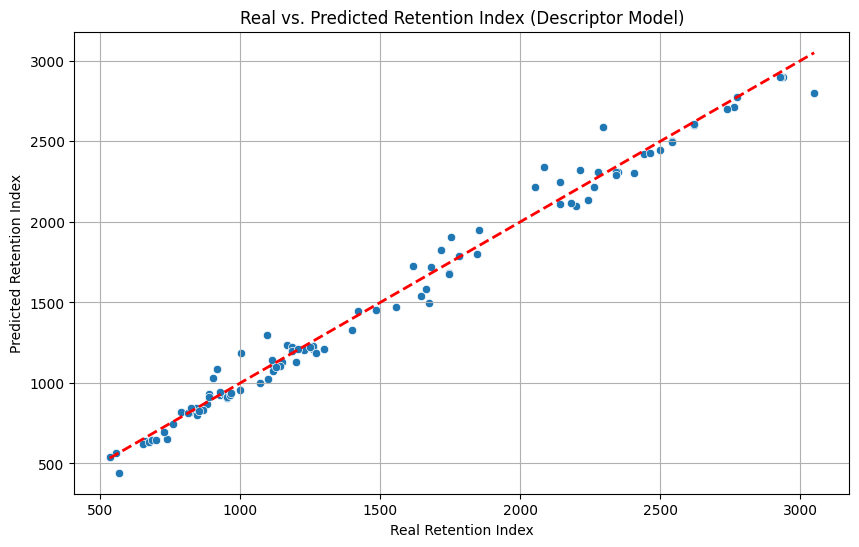

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add y=x line for perfect prediction
plt.title('Real vs. Predicted Retention Index (Descriptor Model)')
plt.xlabel('Real Retention Index')
plt.ylabel('Predicted Retention Index')
plt.grid(True)
plt.show()

In [43]:
feature_importance = pd.DataFrame({'Descriptor': descriptor_columns, 'Coefficient': model.coef_})
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance.sort_values(by='Absolute_Coefficient', ascending=False, inplace=True)

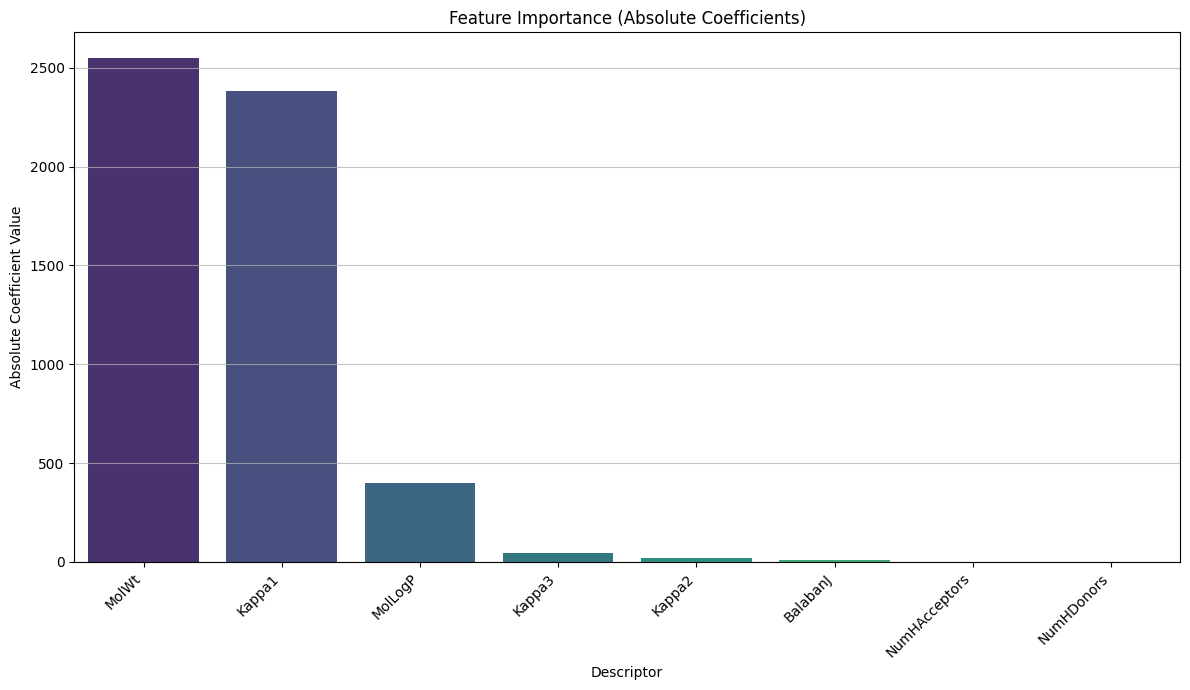

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Descriptor', y='Absolute_Coefficient', data=feature_importance, palette='viridis', hue='Descriptor', legend=False)
plt.title('Feature Importance (Absolute Coefficients)')
plt.xlabel('Descriptor')
plt.ylabel('Absolute Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Interpreting Feature Importance

This graph shows us which molecular descriptors (features) had the biggest impact on our model's predictions. The taller the bar, the more influential that descriptor is. For our model, `Kappa1`, `MolLogP`, and `MolWt` are the most important features in predicting the retention index.

Kappa1 (Kappa one) is a molecular descriptor that is part of the Kappa shape indices developed by Kier and Hall. It is a topological descriptor related to the size and branching of a molecule. In simpler terms, it helps quantify how branched or linear a molecule is, with lower values generally indicating more branching and higher values indicating more linearity for molecules of similar size. It's often used in quantitative structure-activity relationship (QSAR) studies to model molecular properties.

## 9 Improve model

To make our model even better, we can try several strategies:

*   **Try other models:** Our current model is a simple Linear Regression. We could experiment with more complex models like Random Forest Regressors, Gradient Boosting (XGBoost/LightGBM), or Support Vector Regressors. Each model has different strengths and might capture relationships in the data more effectively.

*   **Add other descriptors:** We've used a few RDKit descriptors. There are many more available! Exploring additional molecular descriptors could provide the model with more information about the molecules, potentially leading to better predictions.

*   **Use molecular fingerprints:** Instead of just descriptors, we can use molecular fingerprints (like the Morgan fingerprints we calculated earlier). Fingerprints represent the presence or absence of specific molecular substructures as a binary vector, which can be very powerful for machine learning tasks.

## 10 Save, load and use model

In [26]:
# save model
import pickle
with open('/content/drive/MyDrive/COAST COURSE/FINAL/model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [27]:
# load model
with open('/content/drive/MyDrive/COAST COURSE/FINAL/model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [31]:
# use model
new_smiles = ['CC(C)CC','CCCCCOC', 'C(C)C(C)CCC', 'CC(C(CC)C)CC', 'CCCCCCCCC', 'CCCCCCCCCC' ]

# Create a DataFrame for the new molecule
new_df = pd.DataFrame({'SMILES': new_smiles})

# Add mol objects for the new molecule
from rdkit import Chem
new_df['mol'] = new_df['SMILES'].apply(Chem.MolFromSmiles)

# Calculate descriptors for the new molecule
from rdkit.Chem import Descriptors
new_df['MolWt'] = new_df['mol'].apply(Descriptors.MolWt)
new_df['MolLogP'] = new_df['mol'].apply(Descriptors.MolLogP)
new_df['NumHDonors'] = new_df['mol'].apply(Descriptors.NumHDonors)
new_df['NumHAcceptors'] = new_df['mol'].apply(Descriptors.NumHAcceptors)
#new_df['NumHeavyAtoms'] = new_df['mol'].apply(lambda mol: mol.GetNumHeavyAtoms())
new_df['BalabanJ'] = new_df['mol'].apply(Descriptors.BalabanJ)
new_df['Kappa1'] = new_df['mol'].apply(Descriptors.Kappa1)
new_df['Kappa2'] = new_df['mol'].apply(Descriptors.Kappa2)
new_df['Kappa3'] = new_df['mol'].apply(Descriptors.Kappa3)

# Prepare the descriptor features for prediction
X_new_descriptors = new_df[descriptor_columns]

# Make prediction using the loaded model
new_prediction = loaded_model.predict(X_new_descriptors)



In [32]:
# Retention index predictions
new_prediction

array([457.73516611, 551.6591429 , 644.73742184, 714.31603696,
       870.48218788, 962.15184331])

Visualizing New Molecules and Their Predicted Retention Indices

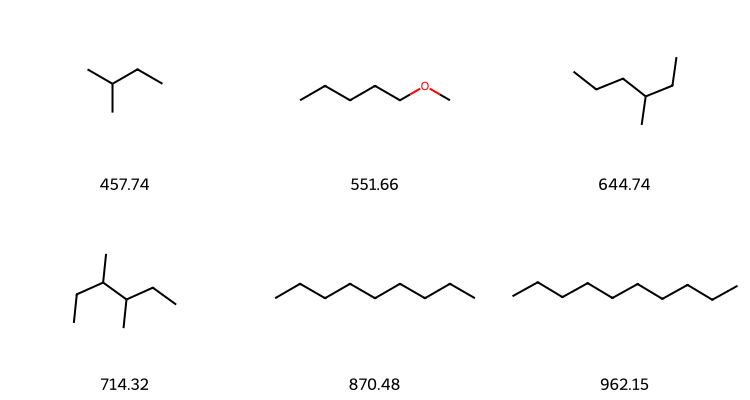

In [33]:
from rdkit.Chem import Draw
from IPython.display import display, Image

img = Draw.MolsToGridImage(
    new_df['mol'],
    molsPerRow=3,
    subImgSize=(250, 200),
    legends=[f"{prediction:.2f}" for prediction in new_prediction]
    )
display(img)

REAMRK: The prediction's reliability for the molecule containing an oxygen atom is questionable if the model was exclusively trained on hydrocarbons.